##Name: Lavish Saini
# Predictive Analysis of Rental Prices in German Metropolitan Areas
Dataset: https://www.kaggle.com/datasets/corrieaar/apartment-rental-offers-in-germany

M516 Business Project in Big Data & AI

In [ ]:
!pip install -q "scikit-learn>=1.3" xgboost pandas numpy matplotlib seaborn joblib shap gradio

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

## 1. Data Loading and Initial Inspection

In [ ]:
df = pd.read_csv("immo_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (268850, 49)


,regio1,serviceCharge,heatingType,telekomTvOffer,telekomHybridUploadSpeed,newlyConst,balcony,picturecount,pricetrend,telekomUploadSpeed,...,regio2,regio3,description,facilities,heatingCosts,energyEfficiencyClass,lastRefurbish,electricityBasePrice,electricityKwhPrice,date
0,Nordrhein_Westfalen,245.00,central_heating,ONE_YEAR_FREE,NaN,False,False,6,4.62,10.0,...,Dortmund,Schüren,Die ebenerdig zu erreichende Erdgeschosswohnun...,Die Wohnung ist mit Laminat ausgelegt. Das Bad...,NaN,NaN,NaN,NaN,NaN,May19
1,Rheinland_Pfalz,134.00,self_contained_central_heating,ONE_YEAR_FREE,NaN,False,True,8,3.47,10.0,...,Rhein_Pfalz_Kreis,Böhl_Iggelheim,Alles neu macht der Mai – so kann es auch für ...,NaN,NaN,NaN,2019.0,NaN,NaN,May19
2,Sachsen,255.00,floor_heating,ONE_YEAR_FREE,10.0,True,True,8,2.72,2.4,...,Dresden,Äußere_Neustadt_Antonstadt,Der Neubau entsteht im Herzen der Dresdner Neu...,"* 9 m² Balkon\n* Bad mit bodengleicher Dusche,...",NaN,NaN,NaN,NaN,NaN,Oct19
3,Sachsen,58.15,district_heating,ONE_YEAR_FREE,NaN,False,True,9,1.53,40.0,...,Mittelsachsen_Kreis,Freiberg,Abseits von Lärm und Abgasen in Ihre neue Wohn...,NaN,87.23,NaN,NaN,NaN,NaN,May19
4,Bremen,138.00,self_contained_central_heating,NaN,NaN,False,True,19,2.46,NaN,...,Bremen,Neu_Schwachhausen,Es handelt sich hier um ein saniertes Mehrfami...,Diese Wohnung wurde neu saniert und ist wie fo...,NaN,NaN,NaN,NaN,NaN,Feb20


In [ ]:
print(df.info())
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268850 entries, 0 to 268849
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   regio1                    268850 non-null  object 
 1   serviceCharge             261941 non-null  float64
 2   heatingType               223994 non-null  object 
 3   telekomTvOffer            236231 non-null  object 
 4   telekomHybridUploadSpeed  45020 non-null   float64
 5   newlyConst                268850 non-null  bool   
 6   balcony                   268850 non-null  bool   
 7   picturecount              268850 non-null  int64  
 8   pricetrend                267018 non-null  float64
 9   telekomUploadSpeed        235492 non-null  float64
 10  totalRent                 228333 non-null  float64
 11  yearConstructed           211805 non-null  float64
 12  scoutId                   268850 non-null  int64  
 13  noParkSpaces              93052 non-null   f

,count,mean,std,min,25%,50%,75%,max
serviceCharge,261941.0,1.512061e+02,3.082958e+02,0.000000e+00,9.500000e+01,1.350000e+02,1.900000e+02,1.461180e+05
telekomHybridUploadSpeed,45020.0,1.000000e+01,0.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01
picturecount,268850.0,9.791958e+00,6.408399e+00,0.000000e+00,6.000000e+00,9.000000e+00,1.300000e+01,1.210000e+02
pricetrend,267018.0,3.389001e+00,1.964874e+00,-1.233000e+01,2.000000e+00,3.390000e+00,4.570000e+00,1.492000e+01
telekomUploadSpeed,235492.0,2.880493e+01,1.633715e+01,1.000000e+00,1.000000e+01,4.000000e+01,4.000000e+01,1.000000e+02
totalRent,228333.0,9.013315e+02,3.323833e+04,0.000000e+00,4.698000e+02,6.500000e+02,9.850000e+02,1.575154e+07
yearConstructed,211805.0,1.966401e+03,4.699221e+01,1.000000e+03,1.950000e+03,1.973000e+03,1.996000e+03,2.090000e+03
scoutId,268850.0,1.069697e+08,1.250093e+07,2.887174e+07,1.066910e+08,1.111584e+08,1.137688e+08,1.157117e+08
noParkSpaces,93052.0,1.327634e+00,8.361403e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.241000e+03
yearConstructedRange,211805.0,3.714544e+00,2.738134e+00,1.000000e+00,1.000000e+00,3.000000e+00,5.000000e+00,9.000000e+00


## 2. Missing Value Analysis

telekomHybridUploadSpeed    83.3
electricityBasePrice        82.6
electricityKwhPrice         82.6
energyEfficiencyClass       71.1
lastRefurbish               70.0
heatingCosts                68.2
noParkSpaces                65.4
petsAllowed                 42.6
interiorQual                41.9
thermalChar                 39.6
numberOfFloors              36.4
houseNumber                 26.4
streetPlain                 26.4
condition                   25.5
yearConstructed             21.2
yearConstructedRange        21.2
firingTypes                 21.2
facilities                  19.7
floor                       19.1
heatingType                 16.7
totalRent                   15.1
typeOfFlat                  13.6
telekomUploadSpeed          12.4
telekomTvOffer              12.1
description                  7.3
serviceCharge                2.6
pricetrend                   0.7
dtype: float64


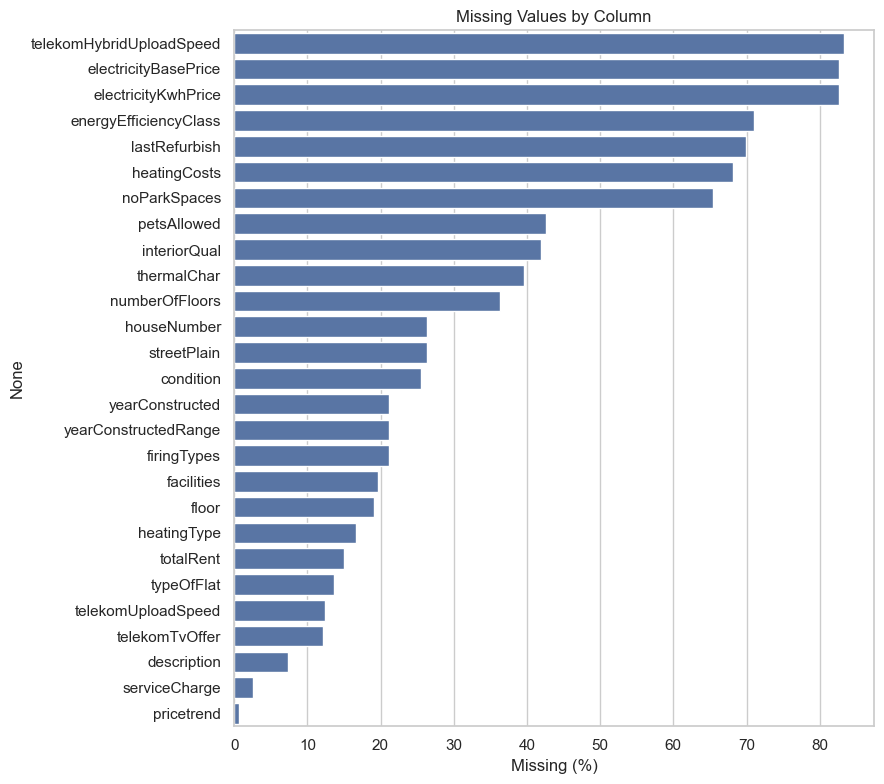

In [ ]:
missing = df.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]
print(missing.round(1))

plt.figure(figsize=(9, 8))
sns.barplot(x=missing.values, y=missing.index, color="#4C72B0")
plt.xlabel("Missing (%)")
plt.title("Missing Values by Column")
plt.tight_layout()
plt.show()

## 3. Target Variable Preparation
Target = `baseRent`. Implausible values are removed and a log transform is applied to correct the heavy right-skew.

Rows after filtering: 268662


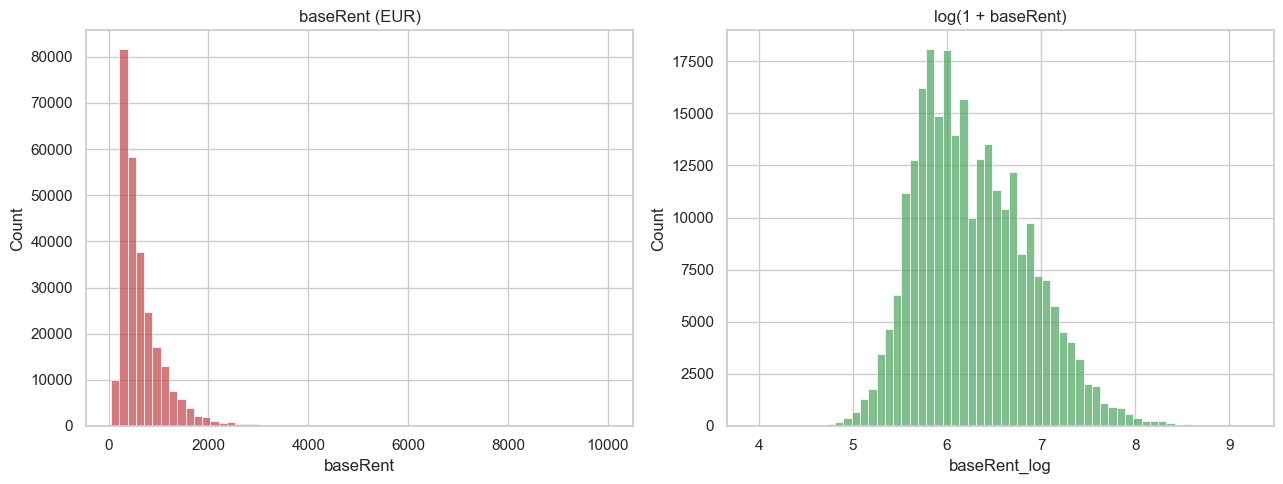

In [ ]:
TARGET = "baseRent"
df = df[(df[TARGET] >= 50) & (df[TARGET] <= 10000)].copy()
df["baseRent_log"] = np.log1p(df[TARGET])
print("Rows after filtering:", len(df))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df[TARGET], bins=60, ax=ax[0], color="#C44E52")
ax[0].set_title("baseRent (EUR)")
sns.histplot(df["baseRent_log"], bins=60, ax=ax[1], color="#55A868")
ax[1].set_title("log(1 + baseRent)")
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis

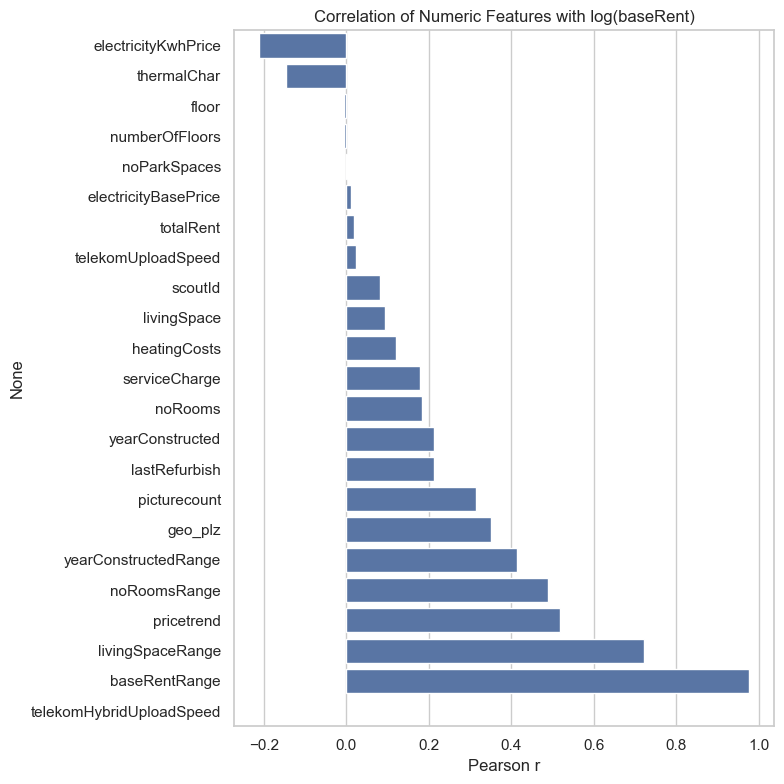

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()["baseRent_log"].drop(["baseRent_log", "baseRent"]).sort_values()

plt.figure(figsize=(8, 8))
sns.barplot(x=corr.values, y=corr.index, color="#4C72B0")
plt.title("Correlation of Numeric Features with log(baseRent)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

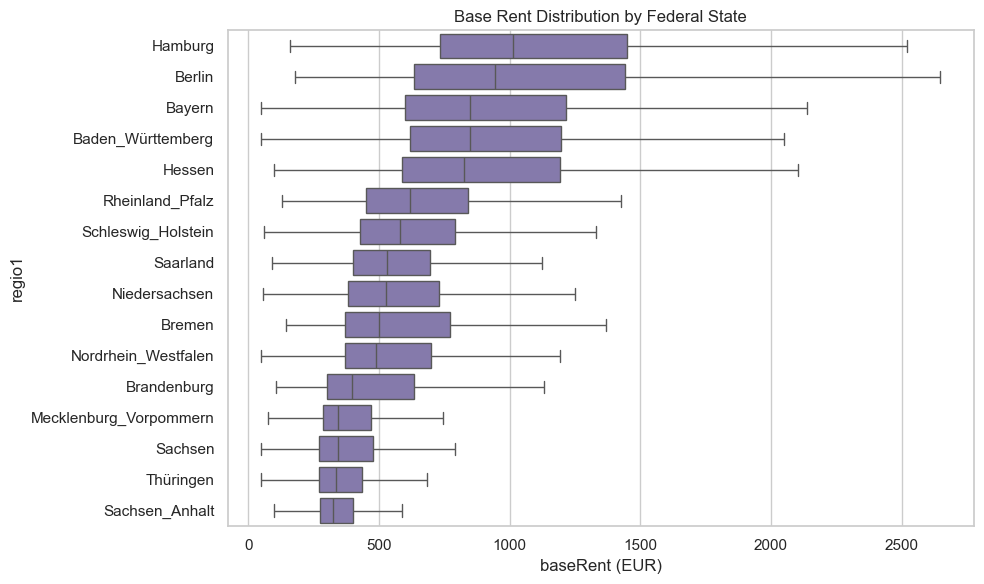

In [ ]:
order = df.groupby("regio1")[TARGET].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x=TARGET, y="regio1", order=order, showfliers=False, color="#8172B3")
plt.title("Base Rent Distribution by Federal State")
plt.xlabel("baseRent (EUR)")
plt.tight_layout()
plt.show()

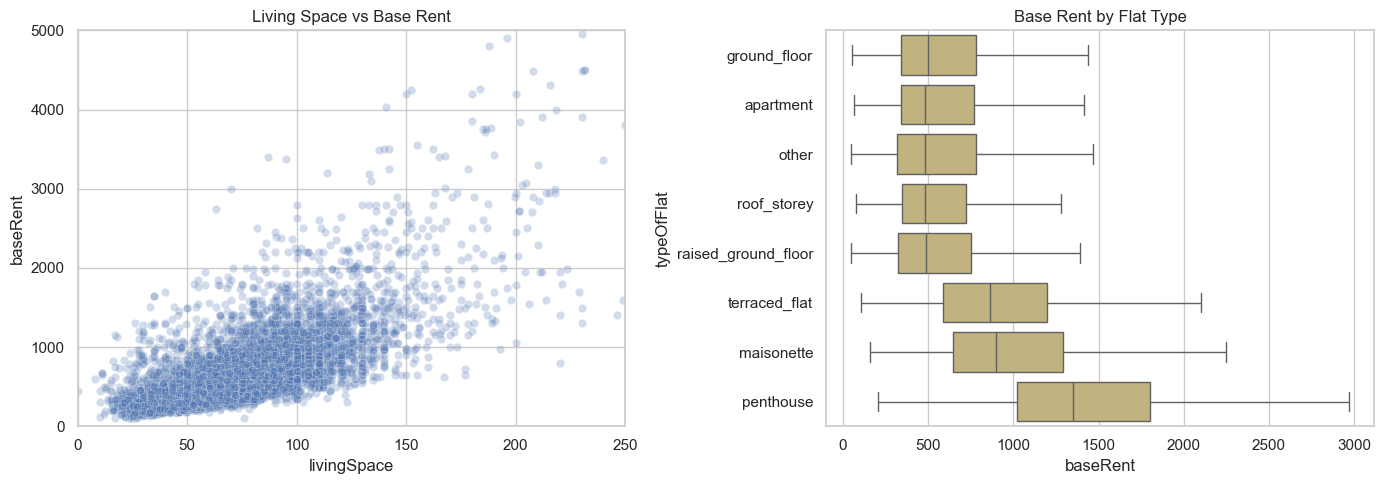

In [ ]:
sample = df.sample(8000, random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=sample, x="livingSpace", y=TARGET, alpha=0.25, ax=ax[0])
ax[0].set_xlim(0, 250); ax[0].set_ylim(0, 5000)
ax[0].set_title("Living Space vs Base Rent")

top_types = df["typeOfFlat"].value_counts().head(8).index
sns.boxplot(data=df[df["typeOfFlat"].isin(top_types)], x=TARGET, y="typeOfFlat",
            showfliers=False, ax=ax[1], color="#CCB974")
ax[1].set_title("Base Rent by Flat Type")
plt.tight_layout()
plt.show()

## 5. Feature Engineering and Cleaning
Engineered features are created, then identifier and leakage columns are removed.

In [ ]:
df["building_age"] = 2020 - df["yearConstructed"]
df["desc_len"] = df["description"].fillna("").str.len()
df["fac_len"] = df["facilities"].fillna("").str.len()

leakage_id_cols = [
    "totalRent", "baseRentRange", "serviceCharge", "heatingCosts",
    "scoutId", "houseNumber", "street", "streetPlain",
    "description", "facilities", "geo_plz", "geo_krs", "regio3",
    "firingTypes", "telekomHybridUploadSpeed", "electricityBasePrice",
    "electricityKwhPrice", "date", "geo_bln",
]

y = df["baseRent_log"]
X = df.drop(columns=leakage_id_cols + [TARGET, "baseRent_log"])

for c in X.select_dtypes(include=["bool"]).columns:
    X[c] = X[c].astype(int)

print("Feature matrix:", X.shape)

Feature matrix: (268662, 32)


In [ ]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
high_card = [c for c in categorical_features if X[c].nunique() > 30]
low_card = [c for c in categorical_features if c not in high_card]

print("Numeric:", len(numeric_features))
print("Low-cardinality categorical:", low_card)
print("High-cardinality categorical:", high_card)

Numeric: 23
Low-cardinality categorical: ['regio1', 'heatingType', 'telekomTvOffer', 'condition', 'interiorQual', 'petsAllowed', 'typeOfFlat', 'energyEfficiencyClass']
High-cardinality categorical: ['regio2']


## 6. Preprocessing Pipeline and Train/Test Split

In [ ]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
low_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(random_state=RANDOM_STATE)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("low", low_card_pipe, low_card),
    ("high", high_card_pipe, high_card),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (214929, 32) | Test: (53733, 32)


## 7. Model Comparison via Cross-Validation
Six models are compared with 3-fold CV on a representative subsample to keep runtime manageable.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(n_estimators=120, n_jobs=-1, random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=400, max_depth=8, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, n_jobs=-1),
}

cv_sample = X_train.sample(n=min(60000, len(X_train)), random_state=RANDOM_STATE)
y_cv_sample = y_train.loc[cv_sample.index]

cv_rows = []
for name, model in models.items():
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe, cv_sample, y_cv_sample, cv=3,
        scoring=["neg_root_mean_squared_error", "r2"], n_jobs=-1,
    )
    cv_rows.append({
        "Model": name,
        "CV_RMSE_log": -scores["test_neg_root_mean_squared_error"].mean(),
        "CV_R2": scores["test_r2"].mean(),
    })
    print(f"{name:24s} done")

cv_results = pd.DataFrame(cv_rows).sort_values("CV_R2", ascending=False).reset_index(drop=True)
cv_results

Linear Regression        done
Ridge                    done
Lasso                    done
Random Forest            done
Hist Gradient Boosting   done
XGBoost                  done


,Model,CV_RMSE_log,CV_R2
0,XGBoost,0.176142,0.913064
1,Hist Gradient Boosting,0.185610,0.903481
2,Random Forest,0.189027,0.899897
3,Linear Regression,0.221884,0.862100
4,Ridge,0.221885,0.862099
5,Lasso,0.223559,0.860012


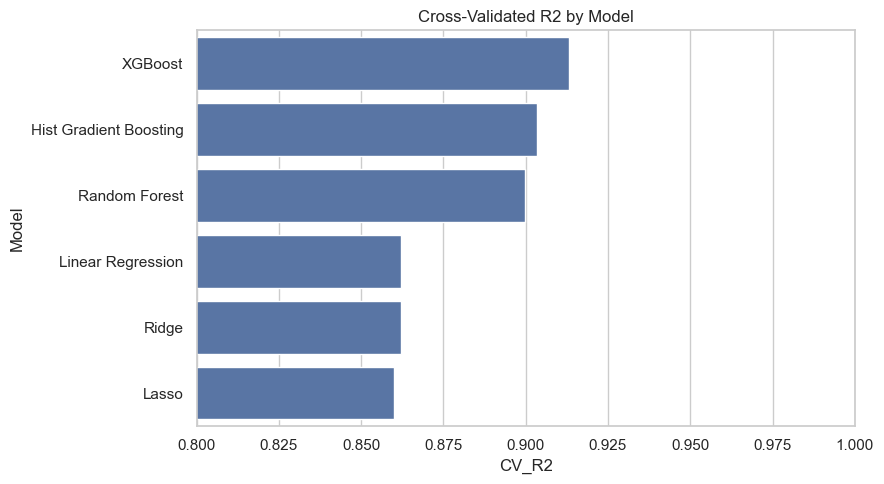

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=cv_results, x="CV_R2", y="Model", color="#4C72B0")
plt.title("Cross-Validated R2 by Model")
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

## 8. Test-Set Evaluation (Euro scale)
Each model is trained on the full training set and evaluated on the held-out test set, with errors reported in euros.

In [ ]:
def euro_metrics(y_true_log, y_pred_log):
    yt, yp = np.expm1(y_true_log), np.expm1(y_pred_log)
    return {
        "R2": r2_score(y_true_log, y_pred_log),
        "RMSE_EUR": np.sqrt(mean_squared_error(yt, yp)),
        "MAE_EUR": mean_absolute_error(yt, yp),
    }

test_rows = []
for name, model in models.items():
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    test_rows.append({"Model": name, **euro_metrics(y_test, pred)})
    print(f"{name:24s} trained")

results = pd.DataFrame(test_rows).sort_values("R2", ascending=False).reset_index(drop=True)
results.round(3)

Linear Regression        trained
Ridge                    trained
Lasso                    trained
Random Forest            trained
Hist Gradient Boosting   trained
XGBoost                  trained


,Model,R2,RMSE_EUR,MAE_EUR
0,XGBoost,0.923,166.197,85.427
1,Random Forest,0.918,174.275,86.972
2,Hist Gradient Boosting,0.910,181.882,93.489
3,Ridge,0.867,224.835,116.373
4,Linear Regression,0.867,224.854,116.382
5,Lasso,0.864,227.492,117.332


## 9. Hyperparameter Tuning (XGBoost)
Randomised search on a subsample, then the best configuration is refit on the full training set.

In [ ]:
search_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_dist = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [6, 8, 10],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
}

tune_sample = X_train.sample(n=min(60000, len(X_train)), random_state=RANDOM_STATE)
y_tune = y_train.loc[tune_sample.index]

search = RandomizedSearchCV(
    search_pipe, param_dist, n_iter=15, cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=1, verbose=1,
)
search.fit(tune_sample, y_tune)

best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
print("Best parameters:", best_params)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


In [ ]:
final_model = Pipeline([
    ("pre", preprocessor),
    ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params)),
])
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)
final_scores = euro_metrics(y_test, final_pred)
print("Final tuned XGBoost:")
for k, v in final_scores.items():
    print(f"  {k}: {v:.3f}")

Final tuned XGBoost:
  R2: 0.928
  RMSE_EUR: 162.075
  MAE_EUR: 81.925


## 10. Final Model Diagnostics

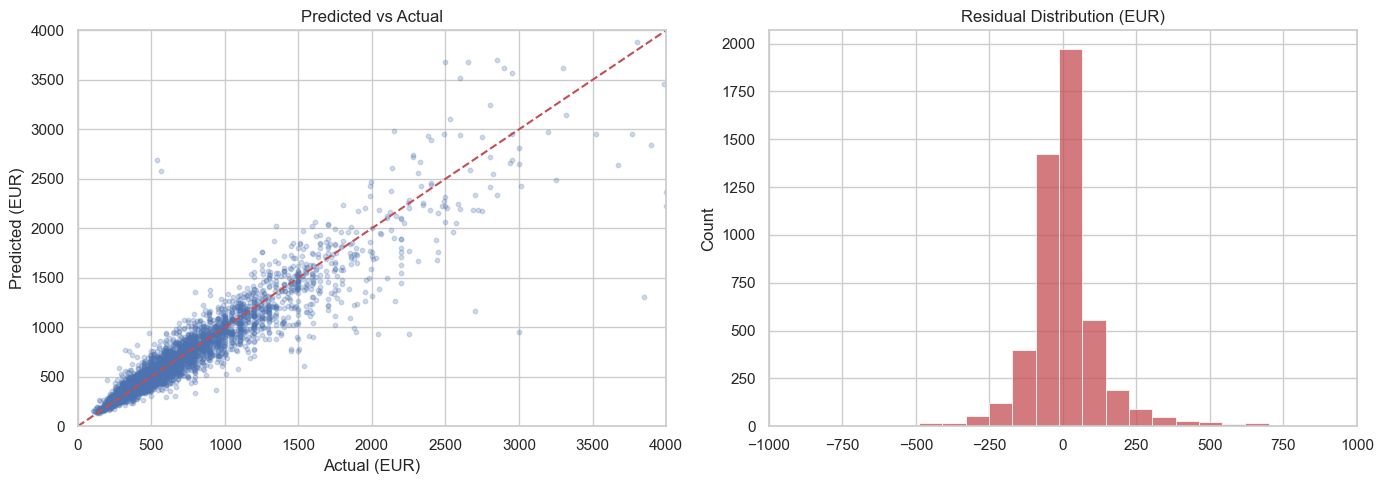

In [ ]:
yt = np.expm1(y_test.values)
yp = np.expm1(final_pred)
idx = np.random.RandomState(RANDOM_STATE).choice(len(yt), 5000, replace=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(yt[idx], yp[idx], alpha=0.25, s=10)
lim = [0, 4000]
ax[0].plot(lim, lim, "r--")
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("Actual (EUR)"); ax[0].set_ylabel("Predicted (EUR)")
ax[0].set_title("Predicted vs Actual")

resid = yt[idx] - yp[idx]
sns.histplot(resid, bins=60, ax=ax[1], color="#C44E52")
ax[1].set_xlim(-1000, 1000)
ax[1].set_title("Residual Distribution (EUR)")
plt.tight_layout()
plt.show()

## 11. Feature Importance

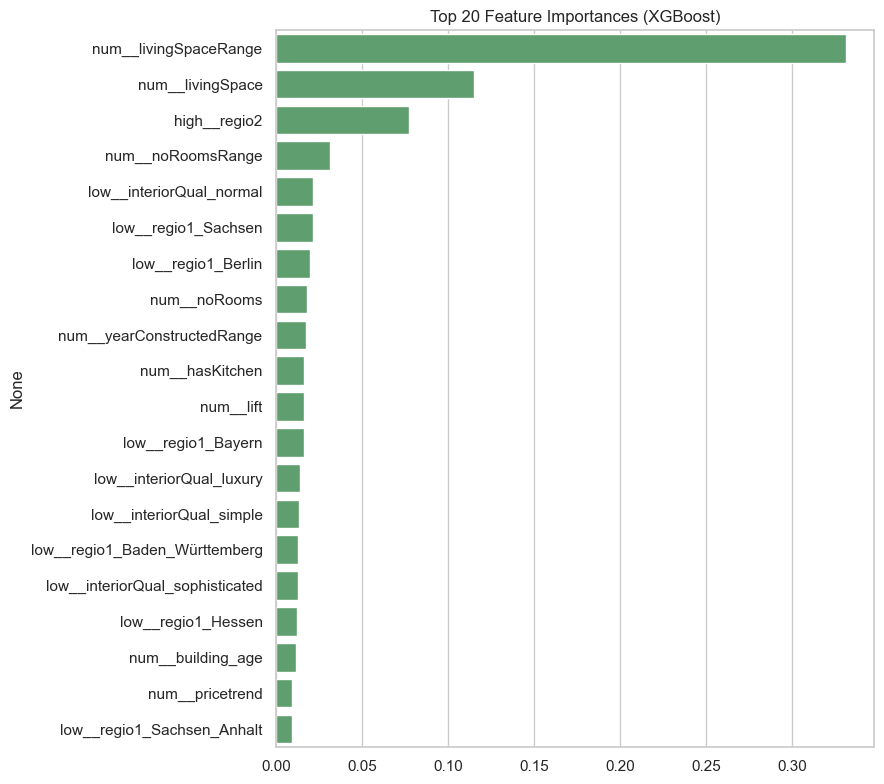

In [ ]:
feat_names = final_model.named_steps["pre"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_
fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 8))
sns.barplot(x=fi.values, y=fi.index, color="#55A868")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

## 12. Model Explainability with SHAP

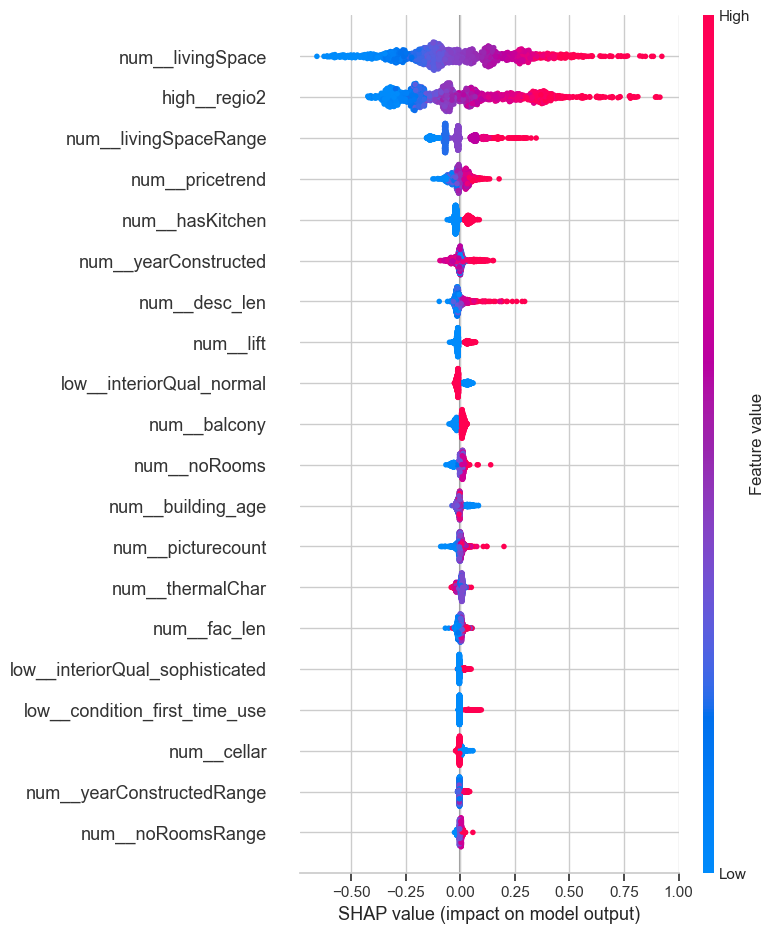

In [ ]:
import shap

shap_sample = X_test.sample(1500, random_state=RANDOM_STATE)
shap_transformed = final_model.named_steps["pre"].transform(shap_sample)
explainer = shap.TreeExplainer(final_model.named_steps["model"])
shap_values = explainer.shap_values(shap_transformed)

shap.summary_plot(shap_values, shap_transformed, feature_names=feat_names, show=True)

## 13. Persisting the Model

In [ ]:
joblib.dump(final_model, "rental_price_model.joblib")
print("Saved: rental_price_model.joblib")

Saved: rental_price_model.joblib


## 14. Prediction Function and Interactive Demo

In [ ]:
defaults = {}
for c in X.columns:
    defaults[c] = X[c].median() if c in numeric_features else X[c].mode().iloc[0]

def predict_rent(**kwargs):
    row = defaults.copy()
    row.update(kwargs)
    record = pd.DataFrame([row])[X.columns]
    return float(np.expm1(final_model.predict(record)[0]))

print("Berlin, 80 m2, 3 rooms:", round(predict_rent(
    livingSpace=80, noRooms=3, regio1="Berlin", regio2="Berlin", typeOfFlat="apartment"), 2), "EUR")
print("Leipzig, 45 m2, 2 rooms:", round(predict_rent(
    livingSpace=45, noRooms=2, regio1="Sachsen", regio2="Leipzig", typeOfFlat="apartment"), 2), "EUR")

Berlin, 80 m2, 3 rooms: 777.54 EUR
Leipzig, 45 m2, 2 rooms: 325.36 EUR


In [ ]:
import gradio as gr

regio1_opts = sorted(X["regio1"].dropna().unique().tolist())
regio2_opts = sorted(X["regio2"].dropna().unique().tolist())
flat_opts = sorted(X["typeOfFlat"].dropna().unique().tolist())
cond_opts = sorted(X["condition"].dropna().unique().tolist())

def app_predict(living_space, rooms, year, state, district, flat_type,
                condition, balcony, kitchen, cellar, lift, garden, new_build):
    price = predict_rent(
        livingSpace=living_space, noRooms=rooms, yearConstructed=year,
        building_age=2020 - year, regio1=state, regio2=district,
        typeOfFlat=flat_type, condition=condition,
        balcony=int(balcony), hasKitchen=int(kitchen), cellar=int(cellar),
        lift=int(lift), garden=int(garden), newlyConst=int(new_build),
    )
    return f"Predicted base rent: EUR {price:,.0f} / month"

demo = gr.Interface(
    fn=app_predict,
    inputs=[
        gr.Slider(15, 300, value=70, label="Living space (m2)"),
        gr.Slider(1, 8, value=3, step=1, label="Rooms"),
        gr.Slider(1900, 2020, value=1990, step=1, label="Year constructed"),
        gr.Dropdown(regio1_opts, value="Berlin", label="Federal state"),
        gr.Dropdown(regio2_opts, value="Berlin", label="District (regio2)"),
        gr.Dropdown(flat_opts, value="apartment", label="Flat type"),
        gr.Dropdown(cond_opts, value=cond_opts[0], label="Condition"),
        gr.Checkbox(label="Balcony"),
        gr.Checkbox(label="Fitted kitchen"),
        gr.Checkbox(label="Cellar"),
        gr.Checkbox(label="Lift"),
        gr.Checkbox(label="Garden"),
        gr.Checkbox(label="New build"),
    ],
    outputs=gr.Textbox(label="Result"),
    title="German Rental Price Predictor",
    description="Estimates monthly base rent (Kaltmiete) from apartment features.",
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
